In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.init as init
from torch import autograd as Grad

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm
import matplotlib.tri as mtri
import matplotlib


#import plotly.graph_objects as go

import ipywidgets as widgets
from IPython.display import display
import trimesh

import random
import math

import time
import ose
import json

import copy



import open3d as o3d
print(o3d.__path__)
print('Using open3d version',o3d.__version__)
# Suppress Open3D warnings
o3d.utility.set_verbosity_level(o3d.utility.VerbosityLevel.Error)



from visuals import *


from bns_utils import *
from mesh_processing import *

import differential
import importlib
importlib.reload(differential)
from differential import *

two_pi = 2*torch.pi
diffmod = DifferentialModule()

# Set device priority: MPS > CUDA > CPU

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")


device = torch.device("cpu")


#device = torch.device('cpu')
print(f"Using device: {device}")


def check_for_nans(tensor, name='tensor'):
    if torch.isnan(tensor).any():
        print(f"\n⚠️ NaNs detected in {name}!\n")
        print(f"{name} stats -- min: {tensor.min().item()}, max: {tensor.max().item()}, mean: {tensor.mean().item()}")
        raise ValueError(f"NaNs found in {name}")


['/Users/romywilliamson/miniconda3/envs/bens/lib/python3.8/site-packages/open3d']
Using open3d version 0.18.0
Using device: cpu


In [2]:

with open("configs/surfaces/torus100.json", "r") as f:
    config_dict = json.load(f)


blend_type = config_dict['blend_type']
shape_id = config_dict['shape_id']
coarse_patches_id = config_dict['coarse_patches_id']
angle_flag = config_dict['angle_flag']
overlap_param = config_dict['overlap_param']    # 0.15470053837 < v < 0.73205080756
degree = config_dict['degree'] #polynomial degree
global_scale = config_dict['global_scale']

layer_sizes=[2,3,4]
posenc=None

KeyError: 'blend_type'

In [15]:
import BNS
importlib.reload(BNS)
from BNS import BNS


# instantiate
bns = BNS(layer_sizes, from_file=True, coarse_patches_id=coarse_patches_id, posenc=posenc, angle_flag=angle_flag, overlap_param = overlap_param, degree=degree, global_scale=global_scale, blend_type=blend_type, device=device)


#bns.load_poly_coeffs('models/sphere_normals_reg_0409.pth')
#bns.load_poly_coeffs('models/torus_normals_reg_0309.pth')
#bns.load_poly_coeffs('models/6octsphere.pth')
bns.load_poly_coeffs('models/surfaces/torus7oct.pth')


Using open3d version at ['/Users/romywilliamson/miniconda3/envs/bens/lib/python3.8/site-packages/open3d']
Assiging a halfedge to each vertex.
Preparing V_he for halfedge mesh
Prepared V_he for halfedge mesh.

Optimising V_he.
Finished optimising V_he.

base triangle verts torch.float32
Computing onering data.
Computing rotations.


/Users/romywilliamson/Documents/BNS/bns/BNS.py:405: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  poly_coeffs_data = torch.load(filename, map_location=self.device)


In [16]:
bns.actual_vertex_positions()[0]

tensor([ 0.1748, -0.0571, -0.1538], grad_fn=<AddBackward0>)

In [20]:
bns_visualiser = BNS_visualiser(bns, mesh_res=5, test_flag='poly', blend_type=blend_type, just_onering=False, use_original_mesh=False,
                               show_on_coarse=False)

settings = ['default','normals', 'angle', 'blend', 'bary', 'curv', 'unblended']
settings = ['default', 'normals', 'curv']


bns_visualiser.compute_quantities(settings=settings)

output pts torch.Size([100, 561, 3])
wrt torch.Size([100, 561, 2])
computing normals...
Attempting batched curvature computation...


In [ ]:
bns_visualiser.show_bns(settings=settings)

✅ Screenshot saved: output/default_x.png
✅ Screenshot saved: output/default_y.png
✅ Screenshot saved: output/default_z.png


✅ Screenshot saved: output/cts_area_dist_x.png
✅ Screenshot saved: output/cts_area_dist_y.png
✅ Screenshot saved: output/cts_area_dist_z.png
✅ Screenshot saved: elastic energy_x.png
✅ Screenshot saved: elastic energy_y.png
✅ Screenshot saved: elastic energy_z.png


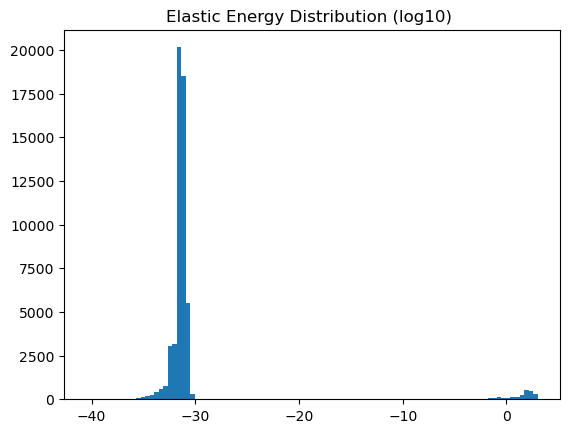

In [11]:
elastic_energy_visualiser.show_bns()

device: cpu


/Users/romywilliamson/miniconda3/envs/bens/lib/python3.8/site-packages/torch/nn/utils/weight_norm.py:134: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/Users/romywilliamson/Documents/BNS/bns/implicit_reps.py:78: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend 

✅ Screenshot saved: output/cts_area_dist_x.png
✅ Screenshot saved: output/cts_area_dist_y.png
✅ Screenshot saved: output/cts_area_dist_z.png
✅ Screenshot saved: elastic energy_x.png
✅ Screenshot saved: elastic energy_y.png
✅ Screenshot saved: elastic energy_z.png


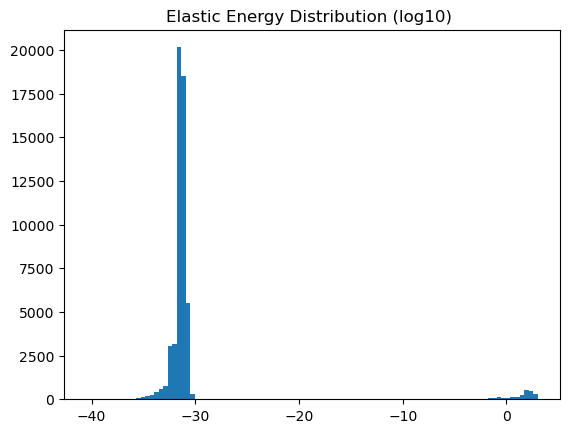

In [7]:
import visuals
importlib.reload(visuals)
from visuals import *


bns.reset()

deformed_bns = copy.deepcopy(bns)


T = torch.zeros_like(bns.V)
#T[3,:] = torch.tensor([-0.2, 0.0, 0.0 ])
#T[3,:] = torch.tensor([-1.2, 0.0, 0.0 ])
T[0,:] = torch.tensor([0.5, 0.0, 0.0 ])

scale = 1.0

deformed_bns.V = scale * deformed_bns.V + T

#deformed_bns.compute_fixed_rotations()


elastic_energy_visualiser = Elastic_energy_visualiser(bns, deformed_bns, mesh_res=5, test_flag='poly',just_onering=False, blend_type=blend_type, use_original_mesh=False,
                               show_on_coarse=False, alpha=1.0, beta=1.0, energy_visual_scale=0.5)

elastic_energy_visualiser.compute_quantities()
elastic_energy_visualiser.show_bns()

In [6]:
# generate training samples
training_sample_dict = bns.compute_samples(num_samples=1000000, avoid_corners=True)
coarse = training_sample_dict['coarse_embedding']


In [7]:
'''

from tqdm import trange

uv = training_sample_dict['uv']
chunk = 10000
B, N, _ = uv.shape

area_dists = []
for i in trange(0, N, chunk, desc="Computing area distortion"):
    wrt = uv[:, i:i+chunk].clone().detach().requires_grad_(True)
    out = bns(wrt, test_flag='poly')
    area_dists.append(diffmod.compute_area_distortion(out=out, wrt=wrt).detach())

area_dist_full = torch.cat(area_dists, dim=1)
print("Final shape:", area_dist_full.shape)
'''


'\n\nfrom tqdm import trange\n\nuv = training_sample_dict[\'uv\']\nchunk = 10000\nB, N, _ = uv.shape\n\narea_dists = []\nfor i in trange(0, N, chunk, desc="Computing area distortion"):\n    wrt = uv[:, i:i+chunk].clone().detach().requires_grad_(True)\n    out = bns(wrt, test_flag=\'poly\')\n    area_dists.append(diffmod.compute_area_distortion(out=out, wrt=wrt).detach())\n\narea_dist_full = torch.cat(area_dists, dim=1)\nprint("Final shape:", area_dist_full.shape)\n'

In [8]:
#training_sample_dict['sample_weighting'] = area_dist_full * 4 / np.sqrt(3)

In [9]:
bns.reset()

deformed_bns = copy.deepcopy(bns)



T = torch.zeros_like(bns.V)
#T[3,:] = torch.tensor([-0.2, 0.0, 0.0 ])
#T[3,:] = torch.tensor([-1.2, 0.0, 0.0 ])
T[0,:] = torch.tensor([0.5, 0.0, 0.0 ])

scale = 1.0

deformed_bns.V = scale * deformed_bns.V + T


In [10]:
############### initial training settings #####################

epoch=0

losses=[]
fractional_epochs=[]
eps = 1.0e-6

epochs=[]
times=[]
num_patches = bns.num_patches

loss=99999


flexible_params = []

'''
#all coefficients for a onering
for name, param in deformed_bns.named_parameters():
    split_name = name.split('.')
    if split_name[0] == 'poly_coeffs' and split_name[1]=='0':
        flexible_params.append(param)
'''

#just the non-constant coefficients - so, vertices are fixed points
for name, param in deformed_bns.named_parameters():
    split_name = name.split('.')
    if split_name[0] == 'poly_coeffs' and split_name[2]!='0':
        flexible_params.append(param)
        
optimizer = optim.Adam(flexible_params, lr=0.001)


In [11]:
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

import implicit_reps
import importlib

# Reload module (useful during development)
importlib.reload(implicit_reps)
from implicit_reps import *


##################### Training Loop ###########################

def train_batch_loop(
    lr: float = 0.01,
    batch_size: int = 10_000,
    min_loss: float = 5e-4,
    batch_print_rate: int = 100,
    batch_plot_rate: int = 10,
    epoch_print_rate: int = 1,
    epoch_save_rate: int = 1,
    epoch_plot_rate: int = 1,
    plot: bool = False,
    flag: str = "poly",
    just_onering: bool = False,
):
    """
    Batch training loop for deformation optimization.

    Args:
        lr (float): Learning rate for optimizer.
        batch_size (int): Number of samples per batch.
        min_loss (float): Stop training once loss drops below this value.
        batch_print_rate (int): Print frequency within batches.
        batch_plot_rate (int): Plot frequency within batches.
        epoch_print_rate (int): Print frequency per epoch.
        epoch_save_rate (int): Model checkpoint frequency.
        epoch_plot_rate (int): Epoch-level plotting frequency.
        plot (bool): Whether to show live plots.
        flag (str): Model evaluation flag.
        just_onering (bool): Whether to restrict training to a single 1-ring.
    """
    global optimizer, losses, times, epoch, loss, num_patches, eps, shape_id

    # Shorthand
    bns1, bns2 = bns, deformed_bns

    # Update learning rate dynamically
    for g in optimizer.param_groups:
        g["lr"] = lr

    # Select indices: one-ring neighborhood or full mesh
    if just_onering:
        select_patch_indices = torch.tensor(
            bns.onerings[0]["triangles"], dtype=torch.long, device=bns.device
        )
    else:
        select_patch_indices = torch.arange(
            bns.F.shape[0], dtype=torch.long, device=bns.device
        )

    seqs, total_points = t_train.shape[0], t_train.shape[1]

    while loss > min_loss:
        perm = torch.randperm(total_points)
        epoch_loss = 0.0

        for i in range(0, total_points, batch_size):
            batch_start = time.time()

            # Sample mini-batch
            idx = perm[i : i + batch_size]
            batch_t = t_train[:, idx, :].clone().detach().requires_grad_(True)
            #batch_sample_weighting = training_sample_dict['sample_weighting'][:, idx]

            optimizer.zero_grad()

            # Forward pass
            out1, _ = bns1(
                batch_t, select_patch_indices=select_patch_indices,
                return_onering_coords=True, test_flag=flag
            )
            out2, _ = bns2(
                batch_t, select_patch_indices=select_patch_indices,
                return_onering_coords=True, test_flag=flag
            )

            # Elastic energy density
            elastic_energy_density, total_energy, FFF = diffmod.elastic_energy_density(
                out1=out1, out2=out2, wrt=batch_t,
                alpha=1.0, beta=1.0, inverse_J1=None, return_total_energy=True
            )


            
            #compute more accurate total energy
            #print(elastic_energy_density.shape, batch_sample_weighting.shape)
            #total_energy = (elastic_energy_density * batch_sample_weighting).mean()

            batch_loss = total_energy

            # Backprop
            batch_loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(bns.parameters(), max_norm=1.0)

            # NaN check
            for name, param in bns.named_parameters():
                if param.grad is not None and torch.isnan(param.grad).any():
                    raise ValueError(f"NaN gradient detected in {name}")

            optimizer.step()

            # Stats
            epoch_loss += batch_loss * batch_t.shape[1]
            batch_time = time.time() - batch_start

            losses.append(batch_loss.item())
            times.append(batch_time)
            fractional_epochs.append(epoch + i / total_points)

            

            # Logging
            if i % batch_print_rate == 0:
                print(f"Batch {i}, Loss: {batch_loss:.8f}, Batch Time: {batch_time:.4f}s")

        # Epoch update
        loss = epoch_loss / total_points
        if epoch % epoch_print_rate == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.8f}")

        if epoch % epoch_save_rate == 0:
            bns.save_poly_coeffs("models/temp.pth")
            print("Saved checkpoint.")

        epoch += 1


device: cpu


/Users/romywilliamson/miniconda3/envs/bens/lib/python3.8/site-packages/torch/nn/utils/weight_norm.py:134: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/Users/romywilliamson/Documents/BNS/bns/implicit_reps.py:67: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend 

In [12]:
t_train = training_sample_dict['uv']

In [15]:
train_batch_loop(lr=0.1, batch_size=1000, min_loss=0.0, batch_plot_rate=10, plot=True)

torch.Size([100, 1000]) torch.Size([100, 1000, 1])
Batch 0, Loss: 0.14049196, Batch Time: 4.7386s
torch.Size([100, 1000]) torch.Size([100, 1000, 1])
Batch 1000, Loss: 0.13545245, Batch Time: 4.7814s
torch.Size([100, 1000]) torch.Size([100, 1000, 1])
Batch 2000, Loss: 0.13362803, Batch Time: 4.8035s
torch.Size([100, 1000]) torch.Size([100, 1000, 1])
Batch 3000, Loss: 0.13134776, Batch Time: 4.7734s
torch.Size([100, 1000]) torch.Size([100, 1000, 1])
Batch 4000, Loss: 0.12831266, Batch Time: 4.8317s
torch.Size([100, 1000]) torch.Size([100, 1000, 1])
Batch 5000, Loss: 0.12451335, Batch Time: 4.7519s
torch.Size([100, 1000]) torch.Size([100, 1000, 1])
Batch 6000, Loss: 0.12162654, Batch Time: 4.7412s
torch.Size([100, 1000]) torch.Size([100, 1000, 1])
Batch 7000, Loss: 0.12023913, Batch Time: 4.6320s
torch.Size([100, 1000]) torch.Size([100, 1000, 1])
Batch 8000, Loss: 0.11824539, Batch Time: 4.6439s
torch.Size([100, 1000]) torch.Size([100, 1000, 1])
Batch 9000, Loss: 0.11758214, Batch Time: 4


KeyboardInterrupt



In [16]:
import visuals
importlib.reload(visuals)
from visuals import *


elastic_energy_visualiser = Elastic_energy_visualiser(bns, deformed_bns, mesh_res=6, test_flag='poly',just_onering=False, blend_type=blend_type, use_original_mesh=False,
                               show_on_coarse=False, alpha=1.0, beta=1.0, energy_visual_scale=0.5)

elastic_energy_visualiser.compute_quantities()
elastic_energy_visualiser.show_bns()

device: cpu
💡 Using custom lighting direction (-0.5, -0.8, -1.0)
✅ Screenshot saved: output/cts_area_dist_x.png
✅ Screenshot saved: output/cts_area_dist_y.png
✅ Screenshot saved: output/cts_area_dist_z.png


KeyboardInterrupt: 

In [ ]:
######### save model ############
ans = input('Would you like to save the model? y/n')
if ans=='y':
    filename = input('What filename would you like to save it as (no extension)?')
    bns.save_poly_coeffs('models/'+filename+'.pth')
    print('Saved model parameters as '+filename+'.pth')
